# 15 · The flight point: `build_flight_point`, line by line, on a real Halo design

`performance/flight_point.py` (454 lines) is the most important orchestration module in the repository. One call couples aerodynamics,
rotor, drive train, electric machines, battery, generators, turboshafts, the optional electrical layer, redundancy states and the thermal
model into **one quasi-steady operating point**. Every requirement, every mission segment and every failure case in the Halo is one call to
it. This notebook reads it in order, then solves points on a sized Halo design.

**In this notebook**
1. `FlightCondition`: what describes a point.
2. What one call adds to the problem: the variables and the equations, traced to their source lines.
3. The function, section by section.
4. A hover point on a sized Halo: reading `FlightPoint`, power flow, margins.
5. The minimum battery share a hover needs.
6. An engine-out hover and a cruise point.
7. Hover power against altitude: required versus available.

**Run time:** about 15 seconds (one small Halo sizing to get a design, then single points).

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect
from dataclasses import replace
from aircraft_closure.performance import flight_point as fp
from aircraft_closure.performance.flight_point import FlightCondition, FlightPoint, build_flight_point
from aircraft_closure.core.margins import margin_report

## 1. `FlightCondition`

In [2]:
print(inspect.getsource(FlightCondition))

@dataclass(frozen=True)
class FlightCondition:
    mode: str = "airplane"
    velocity_m_s: Any = 60.0
    altitude_m: Any = 1000.0
    climb_rate_m_s: Any = 0.0
    thrust_to_weight: Any = 1.0
    active_rotor_count: Any = None
    active_generator_count: Any = None
    soc: Any = 0.8
    hybridization_electric: Any = None
    label: str = "point"
    # Tier 16: ambient temperature minus ISA at the (pressure) altitude; 0 is a standard day.
    temperature_offset_K: Any = 0.0
    # Tier 18 degraded states (Python integers): active lanes per rotor (None: all), active battery strings
    # (None: all) and failed buses (their lanes lost, their sources through a bus tie).
    active_lane_count: Any = None
    active_battery_string_count: Any = None
    count_buses_failed: int = 0

    def __post_init__(self):
        if self.mode not in ("hover", "airplane"):
            raise ValueError(f"Unknown flight mode '{self.mode}'.")



- `mode` is `"hover"` (zero airspeed; thrust per active rotor = $(T/W)\,W / ((1 - DL/T)\,n_\text{active})$) or `"airplane"` (rotors as
  propellers; lift = $W\cos\gamma$, thrust = $D + W\sin\gamma$, $\sin\gamma$ = climb rate / V).
- `soc` is the battery state of charge at the start of the point (a number, or an expression from the mission chain).
- `hybridization_electric`: the battery's share of the bus demand. `None` makes it a **variable** (the energy split is optimized); a number
  prescribes it (requirements usually force 0: sustained capability on turbine power alone).
- The degraded-state fields are Python integers (a failure is not a design variable).

## 2. What one call adds to the problem

Build a point on an empty Opti and look at what appeared. AeroSandbox records where every variable was declared, so we can trace each
one to its line in `flight_point.py`. First we need an aircraft: solve the fast Halo set of tutorial 00 and rebuild its aircraft **with
numbers** (the design as plain floats):

In [3]:
from examples.halo_sizing import (solve_halo_sizing, requirements_tier16, assumptions_tier16, build_halo_aircraft,
                                  build_halo_aerodynamics)
requirements, assumptions = requirements_tier16, assumptions_tier16
result = solve_halo_sizing(requirements, assumptions)
aircraft = build_halo_aircraft(result.design, requirements, assumptions)
aerodynamics = build_halo_aerodynamics(requirements, assumptions)
mass_kg = result.mass_takeoff_kg
print(f"design: MTOM {mass_kg:,.0f} kg, aerodynamics {type(aerodynamics).__name__}")
for name, instance in aircraft.powertrain.topology.instances.items():
    print(f"   {name:<18} {type(instance.component).__name__:<22} x{instance.count}")

design: MTOM 6,242 kg, aerodynamics SimpleAerodynamics
   turboshaft         SimpleTurboshaft       x2
   generator          Generator              x2
   battery            Battery                x1
   motor              Motor                  x2
   gearbox            Gearbox                x2
   propulsor          MomentumProfileRotor   x2
   generator_gearbox  Gearbox                x2


In [4]:
def traced_point(condition, **kwargs):
    opti = asb.Opti()
    point = build_flight_point(opti, aircraft, aerodynamics, condition, mass_kg, **kwargs)
    return opti, point

for condition in (FlightCondition(mode="hover", altitude_m=requirements.altitude_hover_m, thrust_to_weight=1.05, label="hover"),
                  FlightCondition(mode="airplane", velocity_m_s=80.0, altitude_m=3048.0, label="cruise")):
    opti, point = traced_point(condition)
    print(f"--- {condition.label}: {describe_opti(opti)}")
    # AeroSandbox records (file, line, code, size) for every variable it creates.
    for index, (path, line, code, size) in opti._variable_declarations.items():
        print(f"   variable {index}: {path.name}:{line}  {code.strip()[:90]}")

--- hover: {'variables': 4, 'constraints': 10, 'equalities': 2, 'inequalities': 8}
   variable 0: flight_point.py:183  speed_rotor_rad_s = opti.variable(init_guess=100.0, scale=100.0, lower_bound=10.0)
   variable 1: flight_point.py:237  current_battery_A = opti.variable(init_guess=0.0 if has_cooling else 50.0, scale=100.0)
   variable 2: flight_point.py:288  hybridization_electric = opti.variable(init_guess=0.3 if hybridization_electric_min >= 0 e
   variable 3: flight_point.py:291  torque_generator_Nm = opti.variable(init_guess=500.0, scale=500.0, lower_bound=0.0)
--- cruise: {'variables': 5, 'constraints': 15, 'equalities': 3, 'inequalities': 12}
   variable 0: flight_point.py:189  alpha_deg = opti.variable(init_guess=4.0, lower_bound=-5.0, upper_bound=20.0)
   variable 1: flight_point.py:190  speed_rotor_rad_s = opti.variable(init_guess=100.0, scale=100.0, lower_bound=10.0)
   variable 2: flight_point.py:237  current_battery_A = opti.variable(init_guess=0.0 if has_cooling else 50.0

**Hover** creates 4 variables: rotor speed, battery current, the battery share (`hybridization_electric`, since the condition left it
`None`) and generator torque. **Airplane mode** adds the angle of attack. Optional features add more: a thrust-per-rotor variable with the
blown wing, a cooling-drag variable with the thermal model in airplane mode. The equations are the two bus power balances, lift = weight
(airplane mode), the battery branch constraint (equivalent circuit), and inequalities on blade loading, tip Mach, advance ratio, motor
speed, tip speed and stall.

**Note what is *not* constrained: the margins.** `point.margins` is returned for the caller to constrain (or report). A point is a set of
equations plus a list of limits; what to enforce is the caller's decision. Forget that, and a minimum-fuel point will happily overdraw the
battery:

In [5]:
opti, point = traced_point(FlightCondition(mode="hover", altitude_m=requirements.altitude_hover_m, thrust_to_weight=1.05, label="hover"))
opti.minimize(point.fuel_flow_kg_s * 1000)
solution = opti.solve(verbose=False)
worst = margin_report(point.margins, solution.value)[0]
print(f"without margins: battery share {solution.value(point.hybridization_electric):.2f}, worst margin {worst.value:+.2f} ({worst.label})")
check("an unconstrained point violates its limits", worst.value < -0.1)

without margins: battery share 1.00, worst margin -1.53 (hover: battery discharge_power_W)
PASS  an unconstrained point violates its limits


## 3. The function, section by section

`build_flight_point(opti, aircraft, aerodynamics, condition, mass_kg, hybridization_electric=None, *, hybridization_electric_min=0.0,
drag_increments=(), duration_s=0.0, voltage_rc_start_V=None, temperature_start_C=None)`. Read it in this order (each block below prints
the lines it describes).

In [6]:
source = inspect.getsource(build_flight_point)
def show(start_marker, end_marker):
    start = source.find(start_marker)
    end = source.find(end_marker, start)
    print(source[start:end].rstrip() + "\n")

print("(a) components and the degraded state, from the topology")
show("    topology = aircraft.powertrain.topology", "    if condition.mode == \"hover\":")

(a) components and the degraded state, from the topology
    topology = aircraft.powertrain.topology
    instances = topology.instances
    motor_model = instances["motor"].component
    generator_model = instances["generator"].component
    battery_model = instances["battery"].component
    gearbox_model = instances["gearbox"].component
    rotor_model = instances["propulsor"].component
    turboshaft_model = instances["turboshaft"].component
    active_rotor_count = condition.active_rotor_count or instances["propulsor"].count
    active_generator_count = condition.active_generator_count or instances["generator"].count
    # Tier 18: lanes per rotor, active strings and failed buses (all ones for the plain topology).
    state = degraded_state(topology, condition)
    count_lanes_active = state.count_lanes_active
    count_motors_active = active_rotor_count * count_lanes_active
    has_strings = "protection_string" in instances
    has_redundancy = has_strings or state.counts.count_lan

**(a)** Every component comes from the topology by instance name. Active counts come from the condition (rotors, generators) and from
`degraded_state` (lanes, strings, failed buses; tutorial 11). An isolated battery string becomes a smaller pack via `battery_with_strings`.

In [7]:
print("(b) the aerodynamic equilibrium")
show("    if condition.mode == \"hover\":", "    thrust_per_rotor_N = thrust_total_N")

(b) the aerodynamic equilibrium
    if condition.mode == "hover":
        alpha_deg, aero = None, None
        speed_rotor_rad_s = opti.variable(init_guess=100.0, scale=100.0, lower_bound=10.0)
        velocity_m_s = 0.0
        download_fraction = aerodynamics.hover_download_fraction(aircraft)
        thrust_total_N = condition.thrust_to_weight * weight_N / (1 - download_fraction)
    else:
        velocity_m_s = condition.velocity_m_s
        alpha_deg = opti.variable(init_guess=4.0, lower_bound=-5.0, upper_bound=20.0)
        speed_rotor_rad_s = opti.variable(init_guess=100.0, scale=100.0, lower_bound=10.0)
        rotor_state = None
        if getattr(aerodynamics, "blown_wing", None) is not None:
            # Tier 21 blown wing: the slipstream depends on thrust, thrust on drag. Thrust per rotor is a variable
            # tied to the drag by an equality below (no iteration).
            rotor_state = RotorState(opti.variable(init_guess=5000.0, scale=5000.0, lower_bound=0.0),
    

**(b)** Hover: thrust from T/W and the download fraction, no aerodynamics. Airplane: alpha is a variable; lift = weight × cos γ (normalized by
weight); alpha ≤ stall; thrust = drag + cooling drag + weight × sin γ. With a blown wing, thrust per rotor is a variable inside `RotorState`
and an equality ties it to the drag, closing the slipstream–drag loop without iteration.

In [8]:
print("(c) rotor and drive train, run backwards from the rotor")
show("    thrust_per_rotor_N = thrust_total_N", "    # With cooling (Tier 19)")

(c) rotor and drive train, run backwards from the rotor
    thrust_per_rotor_N = thrust_total_N / active_rotor_count
    if condition.mode == "airplane":
        rotor_model = rotor_model.in_airplane_mode()
    speed_motor_limit_rad_s = motor_model.max_speed_rad_s
    rotor = rotor_model.evaluate(velocity_m_s, atmosphere, thrust_N=thrust_per_rotor_N, speed_rad_s=speed_rotor_rad_s)
    # Rotor-speed physics models (Tier 12) return blade loading and helical tip Mach to bound.
    if getattr(rotor_model, "blade_loading_max", None) is not None:
        opti.subject_to(rotor.blade_loading <= rotor_model.blade_loading_max)
    if getattr(rotor_model, "mach_tip_helical_max", None) is not None:
        opti.subject_to(rotor.mach_tip_helical <= rotor_model.mach_tip_helical_max)
    if condition.mode == "airplane" and getattr(rotor_model, "advance_ratio_max", None) is not None:
        opti.subject_to(rotor.advance_ratio <= rotor_model.advance_ratio_max)
    speed_motor_rad_s = gearbox_model.red

**(c)** The rotor evaluates in **thrust mode** (thrust is known), with rotor speed a variable; its blade-loading, tip-Mach and advance-ratio limits
become inequalities right here (they are validity bounds of the model, tutorial 08). Motor speed is gear ratio × rotor speed; gearbox input torque
is rotor power / (η ω); the active lanes share it.

In [9]:
print("(d) battery and bus voltage")
show("    # With cooling (Tier 19)", "    has_layer = \"inverter_motor\" in instances")
show("    if resistances_feeder_ohm:", "    motor = motor_model.evaluate(")

(d) battery and bus voltage
    # With cooling (Tier 19) start at zero current: 50 A held through a long cruise drives the coulomb-counted SOC
    # chain far outside the cell data, and the battery loss there, through the exchanger's cubic pumping law,
    # swamps IPOPT. Without cooling the earlier 50 A start is kept (reference results unchanged).
    current_battery_A = opti.variable(init_guess=0.0 if has_cooling else 50.0, scale=100.0)
    if isinstance(battery_model, EquivalentCircuitBattery):
        battery = battery_model.evaluate(current_battery_A, condition.soc, duration_s, voltage_rc_start_V)
        # Low-current root of R_eff I^2 - V* I + P = 0; also P <= V*^2 / (4 R_eff).
        opti.subject_to(battery.voltage_V / battery.voltage_driving_V >= 0.5)
    else:
        battery = battery_model.evaluate(current_battery_A, condition.soc)

    if resistances_feeder_ohm:
        resistance_battery_feeder_ohm = (resistances_feeder_ohm[0] if len(resistances_feeder_ohm) == 1
        

**(d)** Battery current is a variable, started on the physical side (tutorial 07). The equivalent-circuit pack gets the interval duration and RC
history, and the branch constraint $V \ge V^*/2$. The bus voltage is the battery terminal voltage, less the series drops through string contactors
and feeders when present, or the DC/DC output voltage.

In [10]:
print("(e) motors, the energy split, generators and engines")
show("    motor = motor_model.evaluate(", "    electrical = None")
show("    # Optional step-up gearbox", "    # Tier 19: heat loads by source")

(e) motors, the energy split, generators and engines
    motor = motor_model.evaluate(speed_motor_rad_s, torque_motor_Nm, voltage_bus_V)
    power_electric_motors_W = count_motors_active * motor.power_electric_W
    if has_layer:
        inverter_motor = layer["inverter_motor"].evaluate(motor.power_electric_W, voltage_bus_V)
        current_motor_feeder_A = inverter_motor.power_dc_W / voltage_bus_V
        cable_motor = layer["cable_motor"].evaluate(current_motor_feeder_A)
        protection_motor = layer["protection_motor"].evaluate(current_motor_feeder_A)
        power_motor_bus_W = inverter_motor.power_dc_W + cable_motor.power_loss_W + protection_motor.power_loss_W
        power_electric_motors_W = count_motors_active * power_motor_bus_W
    # Tier 18 bus tie: a failed bus's sources feed the others through one tie (normally open: no current).
    current_tie_A, power_loss_tie_W, tie_ports = 0.0, 0.0, {}
    if state.counts.count_ties:
        if state.count_buses_failed:
           

**(e)** Motor electrical power × active motors is the demand (through inverters, cables and contactors with the electrical layer). The battery share is
a variable in `[hybridization_electric_min, 1]` unless prescribed; a negative minimum lets generators recharge the pack. Each generator runs at its
peak-efficiency speed with a torque variable. The engine shaft follows through the step-up gearbox, and the turboshaft returns fuel flow at this
point's atmosphere.

In [11]:
print("(f) the two power balances (the bus, by construction)")
show("    # Each active turbogenerator carries an equal share", "    port_values = {")

(f) the two power balances (the bus, by construction)
    # Each active turbogenerator carries an equal share of the generator power.
    power_scale_W = active_rotor_count * motor_model.power_rated_W
    if state.counts.count_lanes > 1:
        power_scale_W = power_scale_W * state.counts.count_lanes
    opti.subject_to([
        (power_battery_bus_W - hybridization_electric * power_electric_demand_W) / power_scale_W == 0,
        (active_generator_count * power_generator_bus_W - (1 - hybridization_electric) * power_electric_demand_W)
        / power_scale_W == 0,
        speed_motor_rad_s <= speed_motor_limit_rad_s,
    ])
    if rotor_model.speed_tip_max_m_s is not None:
        opti.subject_to(speed_rotor_rad_s * rotor_model.radius_m() <= rotor_model.speed_tip_max_m_s)



**(f)** The bus closes with **two power equalities**, normalized by the installed motor rating:

$$P_\text{battery,bus} = h\,P_\text{demand},\qquad n_\text{gen}\,P_\text{gen,bus} = (1 - h)\,P_\text{demand}$$

where the demand includes heat-exchanger fan power in hover and bus-tie losses in a bus-out case. Since every port on the bus shares one voltage, these
imply Kirchhoff's current law (tutorial 10).

In [12]:
print("(g) port values -> operating margins, labelled with the condition")
show("    margins_operating = operating_margins(", "    return FlightPoint(")

(g) port values -> operating margins, labelled with the condition
    margins_operating = operating_margins(topology, port_values, atmosphere, components=components_override)
    if state.counts.count_ties and not state.count_buses_failed:
        # Normally open ties: de-energized, no current, no margins.
        margins_operating = tuple(m for m in margins_operating
                                  if not m.label.startswith(("protection_bus_tie ", "cable_bus_tie ")))
    margins = tuple(type(m)(f"{condition.label}: {m.label}", m.value) for m in margins_operating) + thermal.margins



**(g)** The port-value dictionary (tutorial 11) feeds `operating_margins`; normally open ties are dropped; every label gets the condition's label as a
prefix; the thermal margins are appended. Heat loads (`HeatLoad(source, loss per unit, active count)`) were collected along the way and passed to
`evaluate_point_thermal` (tutorial 09).

## 4. A hover point on the sized Halo

The 4,000 ft hover requirement at take-off mass: margins constrained, battery share free, minimum fuel flow (the point is otherwise square, so the
objective only selects among feasible energy splits):

In [13]:
def solve_point(condition, objective="fuel", **kwargs):
    opti = asb.Opti()
    point = build_flight_point(opti, aircraft, aerodynamics, condition, mass_kg, **kwargs)
    opti.subject_to([m.value >= 0 for m in point.margins])
    opti.minimize(point.fuel_flow_kg_s * 1000 if objective == "fuel" else point.hybridization_electric)
    return point, opti.solve(verbose=False)

hover_condition = FlightCondition(mode="hover", altitude_m=requirements.altitude_hover_m, thrust_to_weight=requirements.thrust_to_weight_hover,
                                  label="hover")
point, s = solve_point(hover_condition)
v = s.value
count_rotors = aircraft.powertrain.topology.instances["propulsor"].count
count_generators = aircraft.powertrain.topology.instances["generator"].count
print(f"thrust per rotor {v(point.thrust_per_rotor_N):,.0f} N (download {aerodynamics.hover_download_fraction(aircraft):.1%}), "
      f"rotor speed {v(point.speed_rotor_rad_s):.1f} rad/s, motor {v(point.speed_motor_rad_s):.0f} rad/s at {v(point.torque_motor_Nm):,.0f} N m")
print(f"rotors      {count_rotors * v(point.power_shaft_rotor_W) / 1e3:8.0f} kW shaft")
print(f"motors      {v(point.power_electric_motors_W) / 1e3:8.0f} kW electrical demand")
print(f"battery     {v(point.power_battery_W) / 1e3:8.0f} kW  (share {v(point.hybridization_electric):.3f})")
print(f"generators  {count_generators * v(point.generator.power_electric_W) / 1e3:8.0f} kW electrical, engines {count_generators * v(point.engine.power_shaft_W) / 1e3:.0f} kW shaft")
print(f"fuel flow   {v(point.fuel_flow_kg_s) * 3600:8.1f} kg/h")
print("\ntightest margins:")
for entry in margin_report(point.margins, v)[:6]:
    print(f"   {entry.value:+.4f}  {entry.label}")

thrust per rotor 34,554 N (download 7.0%), rotor speed 58.2 rad/s, motor 1782 rad/s at 435 N m
rotors          1504 kW shaft
motors          1620 kW electrical demand
battery          641 kW  (share 0.396)
generators       979 kW electrical, engines 1054 kW shaft
fuel flow      362.1 kg/h

tightest margins:
   -0.0000  hover: battery discharge_power_W
   -0.0000  hover: propulsor power_shaft_W
   -0.0000  hover: motor power_shaft_W
   -0.0000  hover: gearbox power_input_W
   +0.1194  hover: generator max_voltage_V
   +0.1194  hover: motor max_voltage_V


Minimum fuel at a single point draws the battery to its discharge limit and lets the engines supply the rest (battery energy is "free" at a
point; the mission's SOC chain is what prices it, tutorial 17). The rotor, its gearbox and the motor sit on their ratings: this hover sized the
drive (it is in the binding list of tutorial 00).

## 5. The minimum battery share

Change only the objective: minimize the battery share. The answer is the smallest share of the hover's electrical demand the battery must supply,
because the fixed engines cannot carry it alone. The sizing reports exactly this number for each hover (`HoverSummary.battery_share_min`):

In [14]:
point_min, s_min = solve_point(hover_condition, objective="share")
share_min = s_min.value(point_min.hybridization_electric)
reported = result.hovers[0].battery_share_min
print(f"minimum battery share in the 4,000 ft hover: {share_min:.4f} (the sizing result reports {reported:.4f})")
check("the single point reproduces the sizing's minimum hover battery share", abs(share_min - reported) < 1e-4)

minimum battery share in the 4,000 ft hover: 0.1292 (the sizing result reports 0.1292)
PASS  the single point reproduces the sizing's minimum hover battery share


## 6. An engine-out hover and a cruise point

**Engine-out:** one turbogenerator, sea level, from the 30 % reserve SOC, the battery share free. The constant battery here has no voltage sag, so the
binding limits are powers:

In [15]:
engine_out = FlightCondition(mode="hover", altitude_m=0.0, thrust_to_weight=1.0, active_generator_count=1, soc=0.3, label="engine-out hover")
point_eo, s_eo = solve_point(engine_out)
print(f"battery {s_eo.value(point_eo.power_battery_W) / 1e3:.0f} kW (share {s_eo.value(point_eo.hybridization_electric):.3f}); "
      f"one engine at {s_eo.value(point_eo.engine.power_shaft_W) / 1e3:.0f} kW")
for entry in margin_report(point_eo.margins, s_eo.value)[:5]:
    print(f"   {entry.value:+.4f}  {entry.label}")

battery 641 kW (share 0.453); one engine at 835 kW


   -0.0000  engine-out hover: battery discharge_power_W
   -0.0000  engine-out hover: generator power_shaft_W
   -0.0000  engine-out hover: turboshaft power_shaft_W
   -0.0000  engine-out hover: generator_gearbox power_input_W
   +0.1194  engine-out hover: generator max_voltage_V


**Cruise** at the sized mission's cruise speed and altitude, turbine power only ($h = 0$):

In [16]:
cruise = FlightCondition(mode="airplane", velocity_m_s=result.velocity_cruise_m_s, altitude_m=requirements.altitude_cruise_m,
                         hybridization_electric=0.0, label="cruise")
point_c, s_c = solve_point(cruise)
vc = s_c.value
rotor_c = aircraft.powertrain.topology.instances["propulsor"].component
print(f"alpha {vc(point_c.alpha_deg):.2f} deg, CL {vc(point_c.aero.cl):.3f}, L/D {vc(point_c.aero.lift_to_drag):.2f}, drag {vc(point_c.aero.drag_N):,.0f} N")
print(f"rotor speed {vc(point_c.speed_rotor_rad_s):.1f} rad/s, advance ratio {vc(cruise.velocity_m_s / (point_c.speed_rotor_rad_s * rotor_c.radius_m())):.3f} "
      f"(bound {rotor_c.advance_ratio_max}), propulsive efficiency "
      f"{vc(point_c.thrust_per_rotor_N * cruise.velocity_m_s / point_c.power_shaft_rotor_W):.3f}")
print(f"fuel flow {vc(point_c.fuel_flow_kg_s) * 3600:.0f} kg/h")
check("cruise rotor speed is set by the advance-ratio bound (tutorial 08's pathology)",
      abs(vc(cruise.velocity_m_s / (point_c.speed_rotor_rad_s * rotor_c.radius_m())) - rotor_c.advance_ratio_max) < 1e-4)

alpha 10.87 deg, CL 1.172, L/D 7.29, drag 8,399 N
rotor speed 32.8 rad/s, advance ratio 0.600 (bound 0.6), propulsive efficiency 0.913
fuel flow 300 kg/h
PASS  cruise rotor speed is set by the advance-ratio bound (tutorial 08's pathology)


## 7. Hover power against altitude

The same point at a range of altitudes, each solved twice: on turbine power alone ($h = 0$, until infeasible) and with the battery share free.
This is the hover-ceiling picture, computed from the coupled model rather than from separate power curves:

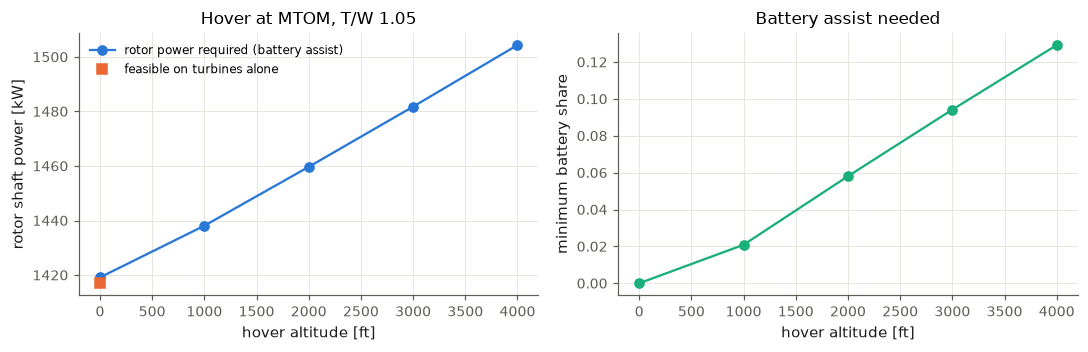

In [17]:
altitudes_ft = onp.arange(0, 12001, 1000)
rows = []
for altitude_ft in altitudes_ft:
    condition = replace(hover_condition, altitude_m=altitude_ft * u.foot, label=f"hover {altitude_ft} ft")
    try:
        p0, s0 = solve_point(replace(condition, hybridization_electric=0.0))
        turbine_only_kW = count_rotors * s0.value(p0.power_shaft_rotor_W) / 1e3
    except RuntimeError:
        turbine_only_kW = onp.nan
    try:
        p1, s1 = solve_point(condition, objective="share")
        rows.append((altitude_ft, count_rotors * s1.value(p1.power_shaft_rotor_W) / 1e3, s1.value(p1.hybridization_electric), turbine_only_kW))
    except RuntimeError:
        rows.append((altitude_ft, onp.nan, onp.nan, turbine_only_kW))
rows = onp.array(rows)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
axes[0].plot(rows[:, 0], rows[:, 1], "o-", color=blue, label="rotor power required (battery assist)")
axes[0].plot(rows[:, 0], rows[:, 3], "s", color=orange, label="feasible on turbines alone")
axes[0].set(xlabel="hover altitude [ft]", ylabel="rotor shaft power [kW]", title="Hover at MTOM, T/W 1.05")
axes[1].plot(rows[:, 0], rows[:, 2], "o-", color=aqua)
axes[1].set(xlabel="hover altitude [ft]", ylabel="minimum battery share", title="Battery assist needed")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

Rotor power rises with altitude (thinner air) while turbine power available falls (lapse), so the battery share needed grows: from zero at
sea level (the only altitude the turbines manage alone, just) to 13 % at 4,000 ft. **Above 4,000 ft every point is infeasible**: the rotor, gearbox
and motor ratings were sized exactly for the 4,000 ft hover requirement, so there is no spare drive power. The plot is the requirement read
backwards: the optimizer bought precisely the hover capability it was asked for.

In [18]:
check("no hover above the 4,000 ft requirement: the drive was sized exactly for it", onp.all(onp.isnan(rows[rows[:, 0] > 4000, 1])))

PASS  no hover above the 4,000 ft requirement: the drive was sized exactly for it


## Summary

- A `FlightCondition` describes the point; `build_flight_point` adds its variables (rotor speed, battery current, generator torque, battery share,
  alpha, plus optional coupling variables) and equations, and returns expressions plus margins.
- The caller constrains the margins; the objective picks among feasible operating states.
- The bus closes with two normalized power balances; connections are written by construction; the topology supplies components, counts and margins.
- The same call serves requirements, mission segments and failure cases.

## Check yourself

<details><summary>1. In a requirement point the code prescribes <code>hybridization_electric=0</code>. In a mission segment it leaves it <code>None</code>. Why?</summary>

A sustained capability (210 kt, ceiling, climb) must hold on turbine power alone, since the battery would run out; prescribing 0 encodes that. In the mission the energy split is a decision the optimizer makes, with the SOC chain accounting for it (tutorial 17).
</details>

<details><summary>2. Where would you add a new loss source (say, a gearbox oil pump drawing from the bus)?</summary>

In `build_flight_point`: compute its power, add it to the bus demand (like the fan power), and add a `HeatLoad` with its source name so the thermal model sees it. If it is a topology instance, also give it ports, margins and a location.
</details>

<details><summary>3. Why does the hover section not create an angle-of-attack variable?</summary>

At zero airspeed the wing produces no lift; the rotors carry the weight plus download. The aerodynamics model only supplies the download fraction.
</details>

In [19]:
check_summary()

4 of 4 checks passed
